In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

In [7]:
def createSomeData(nPerClust):

    A = [1,1]
    B = [5,1]
    C = [4,4]

    a = [ A[0]+np.random.randn(nPerClust), A[1]+np.random.randn(nPerClust) ]
    b = [ B[0]+np.random.randn(nPerClust), B[1]+np.random.randn(nPerClust) ]
    c = [ C[0]+np.random.randn(nPerClust), C[1]+np.random.randn(nPerClust) ]

    labels_np = np.hstack(( np.zeros((nPerClust)),
    np.ones( (nPerClust)),
    1+np.ones( (nPerClust)) ))

    data_np = np.hstack((a,b,c)).T

    output = {}
    output['data'] = torch.tensor(data_np).float()
    output['labels'] = torch.tensor(labels_np).long()

    train_data, test_data, train_labels, test_labels = train_test_split(output['data'], output['labels'], train_size=0.8)

    train_data = TensorDataset(train_data, train_labels)
    test_data = TensorDataset(test_data, test_labels)

    batchsize = 8
    output['train_data'] = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
    output['test_data'] = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

    return output

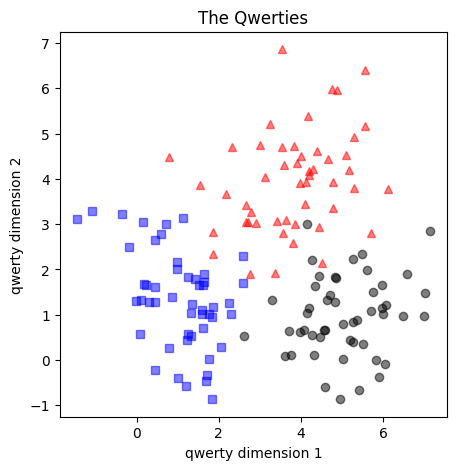

In [9]:
theData = createSomeData(50)

data = theData['data']
labels = theData['labels']

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'^r',alpha=.5)
plt.title('The Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [17]:
def createTheQwertyNet(nUnits, nLayers):

    class qwertyNet(nn.Module):
        def __init__(self, nUnits, nLayers):
            super().__init__()

            self.layers = nn.ModuleDict()
            self.nLayers = nLayers

            self.layers['input'] = nn.Linear(2, nUnits)

            for i in range(nLayers):
                self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

            self.layers['output'] = nn.Linear(nUnits,3)

        def forward(self,x):
            x = self.layers['input'](x)

            for i in range(self.nLayers):
                x = F.relu( self.layers[f'hidden{i}'](x) )

            x = self.layers['output'](x)
            return x
    
    net = qwertyNet(nUnits, nLayers)

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=.01)

    return net, lossfun, optimizer